# 02 – Exploratory Data Analysis (EDA) and Log Transformation



This notebook performs exploratory data analysis (EDA) to:
- Visualize distributions and outliers.
- Decide how to treat them.
- Apply log transformation to skewed numeric features for better normalization.


In [1]:
# --- Import libraries ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from google.colab import drive

In [2]:
# --- Mount Google Drive and set project paths ---
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/classification_project'
data_path = f'{base_path}/data'
results_path = f'{base_path}/results'
os.makedirs(data_path, exist_ok=True)
os.makedirs(results_path, exist_ok=True)

Mounted at /content/drive


In [3]:
# --- Load dataset ---
file_path = f'{data_path}/01_cleaned_cirrhosis.csv'
cirrhosis = pd.read_csv(file_path)
print(f"Dataset loaded successfully from: {file_path}")
print("Shape:", cirrhosis.shape)

Dataset loaded successfully from: /content/drive/MyDrive/classification_project/data/01_cleaned_cirrhosis.csv
Shape: (418, 19)


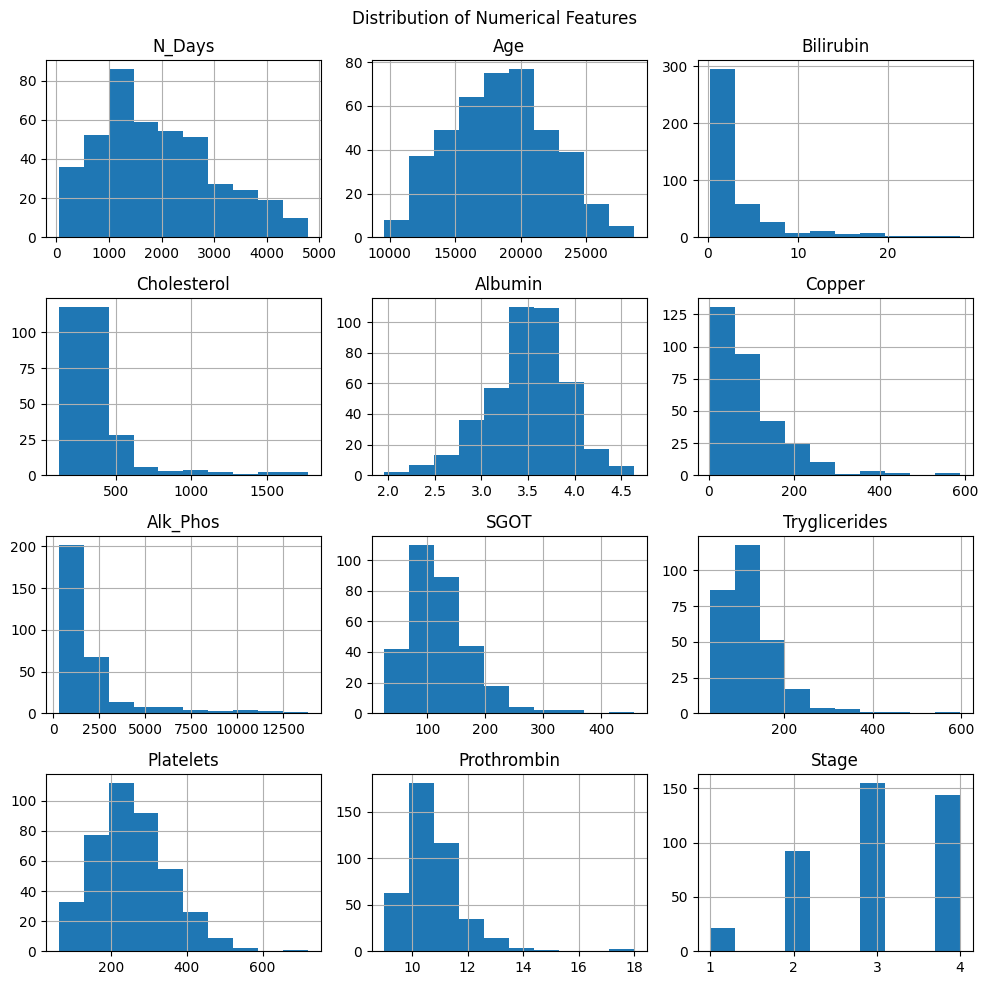

In [4]:
# --- Histograms for all numerical columns ---
fig = cirrhosis.hist(figsize=(10, 10))
plt.suptitle('Distribution of Numerical Features')
plt.tight_layout()
plt.savefig(f"{results_path}/02_histograms_numerical_features.png", bbox_inches='tight')
plt.show()

In [6]:
# --- Boxplots to visualize potential outliers ---
for col in cirrhosis.select_dtypes(include=['float64', 'int64']):
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=cirrhosis, x=col, color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.savefig(f"{results_path}/02_boxplot_{col}.png", bbox_inches='tight')
    plt.close()  # avoid cluttering output

In [7]:
# --- KDE plots for data skewness ---
for col in cirrhosis.select_dtypes(include=['float64', 'int64']):
    plt.figure(figsize=(6, 3))
    sns.kdeplot(cirrhosis[col], fill=True, color='orange')
    plt.title(f'Distribution of {col}')
    plt.savefig(f"{results_path}/02_kdeplot_{col}.png", bbox_inches='tight')
    plt.close()

print("All histogram, boxplot, and KDE plots saved to Drive.")

All histogram, boxplot, and KDE plots saved to Drive.


###  Outlier Discussion

After visualizing the data, several features contain outliers.  
However, these outliers represent real medical phenomena rather than errors — they reflect disease severity.

To handle this properly:
- We **do not remove** the outliers (to preserve medically important values).
- Instead, we apply a **log-transform** to reduce their skewness while keeping the data meaningful.


In [8]:
# --- Log transformation plan ---
features_to_transform = [
    'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
    'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin'
]

cirrhosis_log_transformed = cirrhosis.copy()

for feature in features_to_transform:
    cirrhosis_log_transformed[feature] = np.log1p(cirrhosis[feature])

# --- Verify transformations ---
display(cirrhosis_log_transformed[features_to_transform].describe())

,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin
count,418.000000,284.000000,418.000000,310.000000,312.000000,312.000000,282.000000,407.000000,416.000000
mean,1.125921,5.800504,1.498843,4.279436,7.272987,4.719623,4.730150,5.475632,2.458865
std,0.708078,0.435361,0.097994,0.807743,0.721760,0.443704,0.443343,0.408335,0.081161
min,0.262364,4.795791,1.085189,1.609438,5.669881,3.308717,3.526361,4.143135,2.302585
25%,0.587787,5.523453,1.445152,3.743552,6.771322,4.401829,4.445575,5.244386,2.397895
50%,0.875469,5.738183,1.510722,4.304065,7.138867,4.751001,4.691348,5.529429,2.451005
75%,1.481605,5.993961,1.562346,4.820282,7.591348,5.029784,5.023881,5.765191,2.493205
max,3.367296,7.482119,1.729884,6.378426,9.537008,6.127415,6.395262,6.582025,2.944439


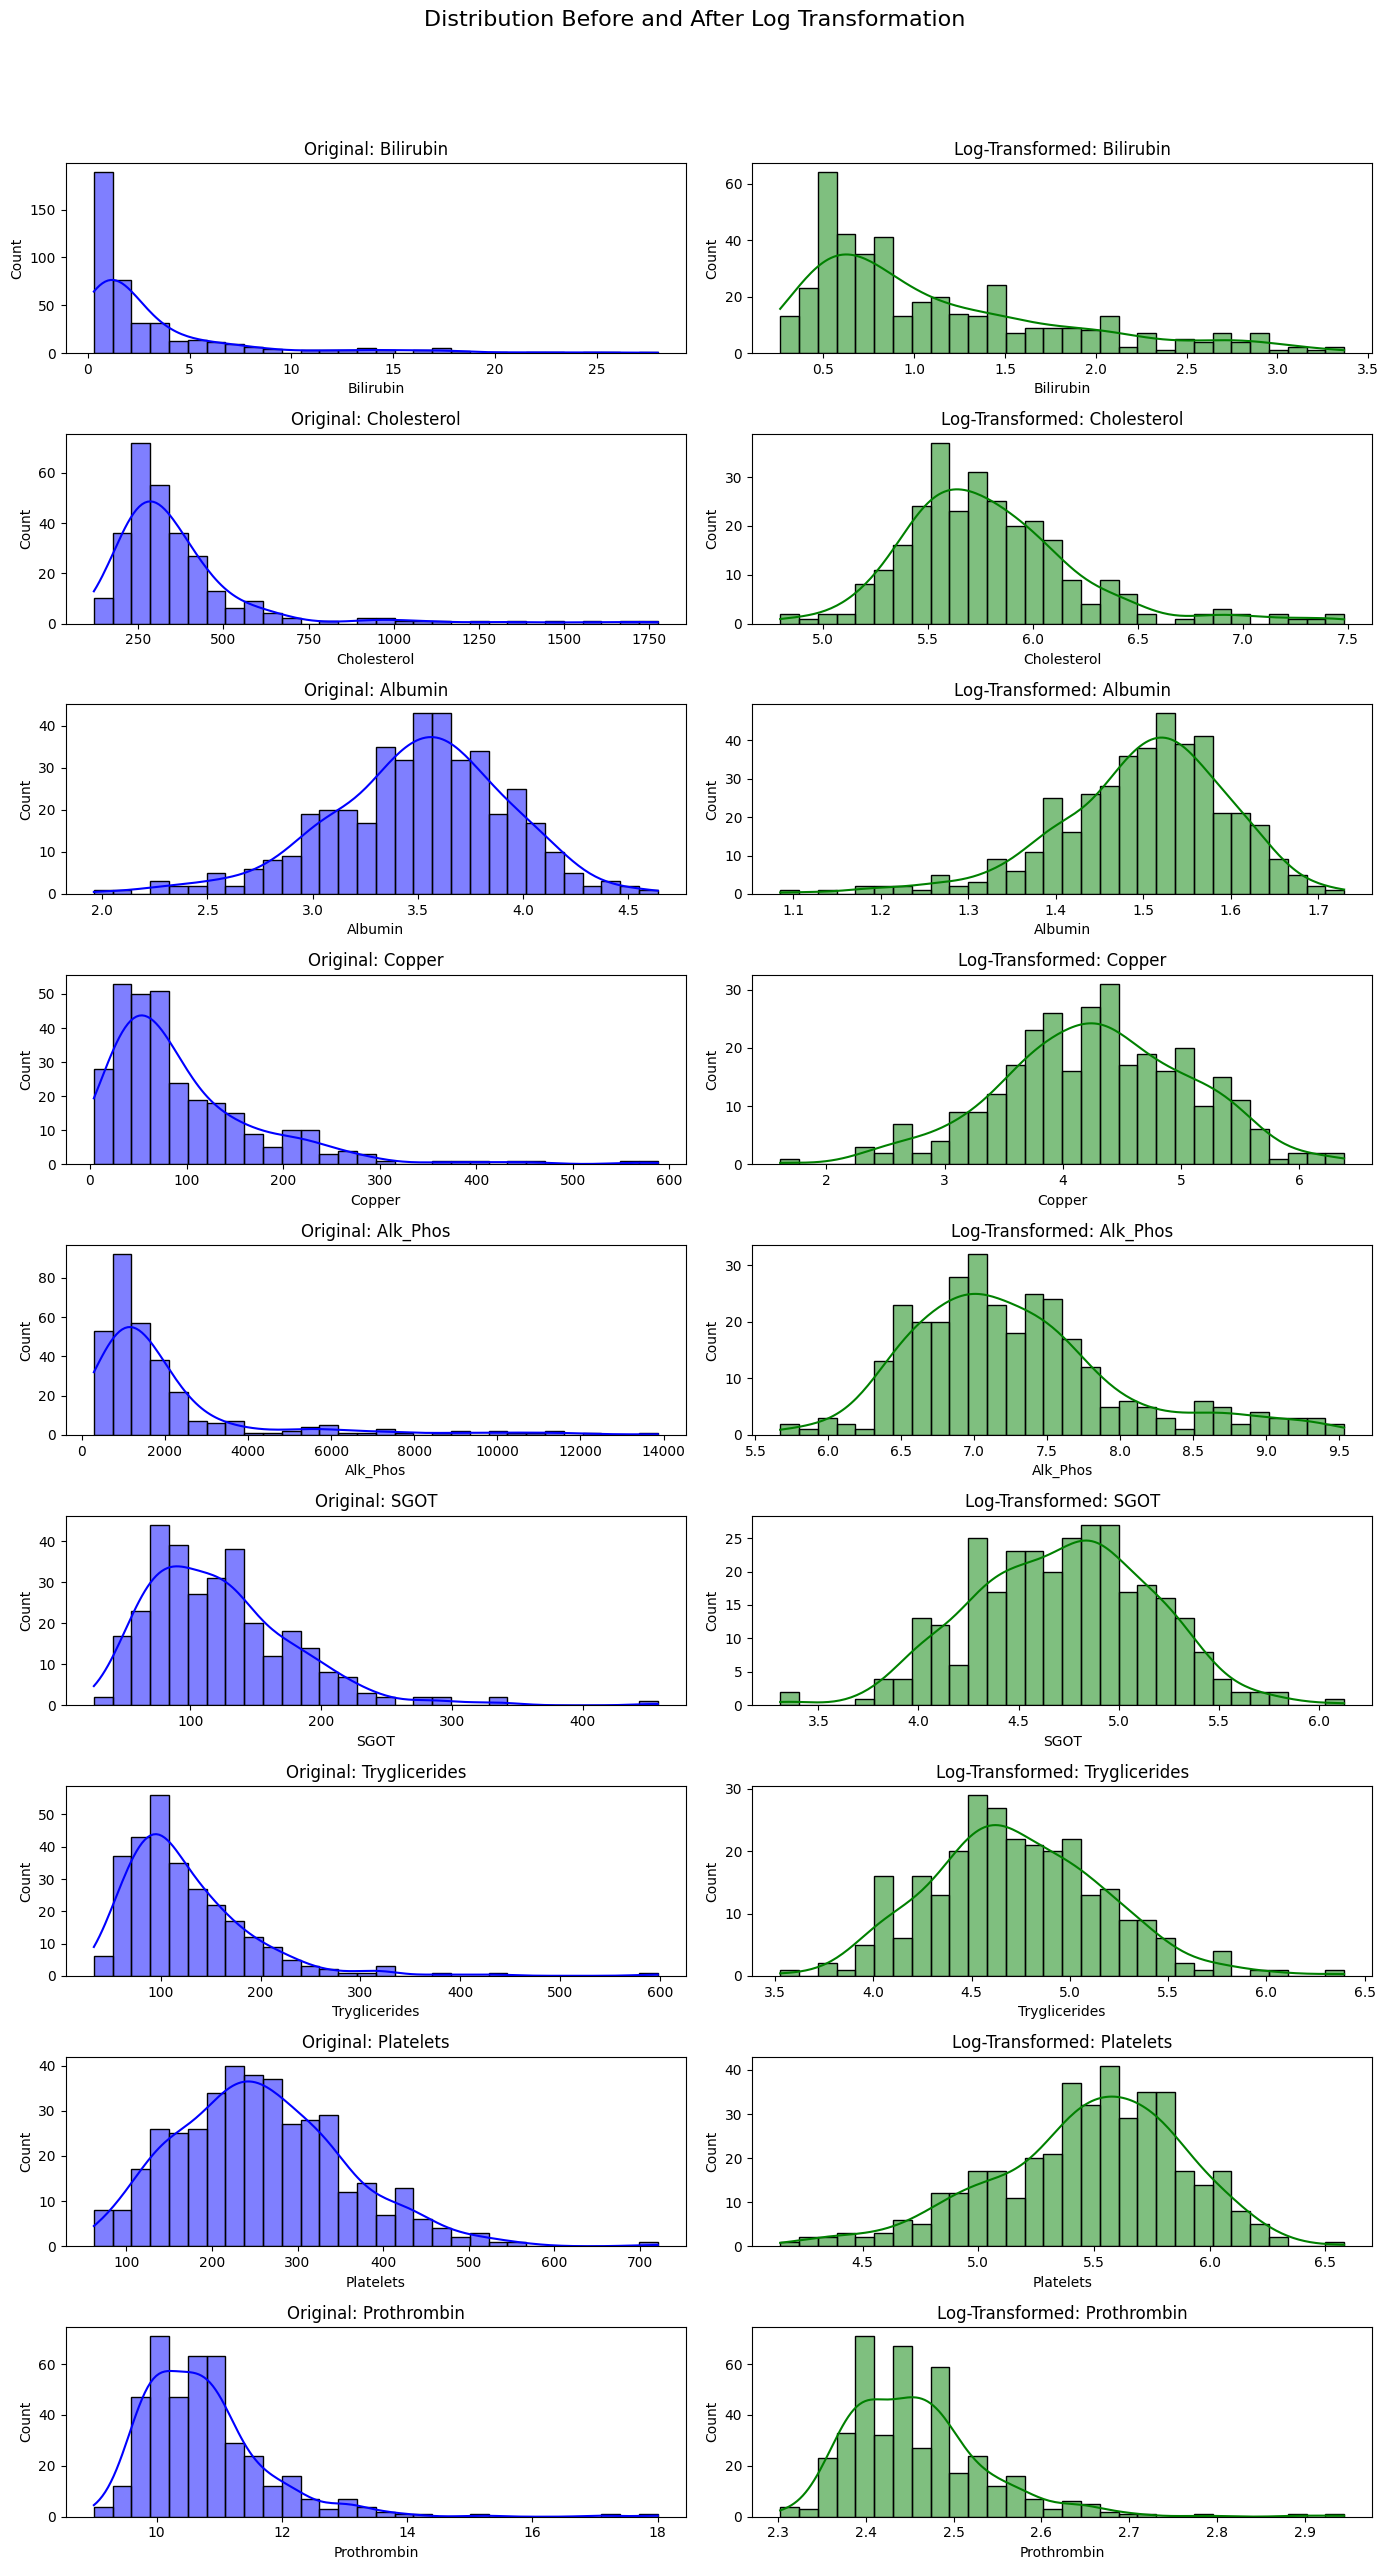

In [9]:
# --- Compare original vs log-transformed distributions ---
fig, axes = plt.subplots(nrows=len(features_to_transform), ncols=2, figsize=(14, 3 * len(features_to_transform)))
fig.suptitle('Distribution Before and After Log Transformation', fontsize=16)

for idx, feature in enumerate(features_to_transform):
    sns.histplot(cirrhosis[feature], bins=30, kde=True, ax=axes[idx, 0], color='blue')
    axes[idx, 0].set_title(f'Original: {feature}')

    sns.histplot(cirrhosis_log_transformed[feature], bins=30, kde=True, ax=axes[idx, 1], color='green')
    axes[idx, 1].set_title(f'Log-Transformed: {feature}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(f"{results_path}/02_log_transform_comparison.png", bbox_inches='tight')
plt.show()

In [10]:
# --- Save log-transformed dataset for next stage ---
save_path = f'{data_path}/02_log_transformed_cirrhosis.csv'
cirrhosis_log_transformed.to_csv(save_path, index=False)
print(f"Log-transformed dataset saved to: {save_path}")
print(f"All figures saved under: {results_path}")

Log-transformed dataset saved to: /content/drive/MyDrive/classification_project/data/02_log_transformed_cirrhosis.csv
All figures saved under: /content/drive/MyDrive/classification_project/results


**Next Notebook:** [03_Missing_Value_Imputation.ipynb](03_Missing_Value_Imputation.ipynb)  
We will handle missing values using appropriate strategies such as mean imputation and MICE imputation.
